In [1]:
import gymnasium as gym
import itertools
import math
import matplotlib
import matplotlib.colors as colors
import matplotlib.pyplot as plt
from matplotlib.tri import Triangulation
import random
import ale_py
import tensorflow as tf
from tensorflow.keras import layers

import torch
import torch.nn as nn
import torch.optim as optim


import subprocess, sys

import numpy as np
import seaborn as sns

from tqdm import tqdm
import collections

# Make plots look nice
sns.set()
sns.set_context("notebook")
sns.set_style("whitegrid")

In [2]:
gym.register_envs(ale_py)

In [3]:
env = gym.make("ALE/Asterix-v5", obs_type="grayscale", frameskip=1)


env = gym.wrappers.AtariPreprocessing(env, frame_skip=4)
env = gym.wrappers.FrameStackObservation(env, 4)


obs, info = env.reset()


#print("Observation space:", env.observation_space)
#print("Action space:", env.action_space)

for _ in range(5):
    action = env.action_space.sample()
    obs, reward, terminated, truncated, info = env.step(action)
    #print(f"obs={obs}, reward={reward:.3f}, done={terminated}")

env.close()
print("✅ All good!")

✅ All good!


In [4]:
class DQN(nn.Module):
    def __init__(self, n_actions):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(4, 32, kernel_size=8, stride=4),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=4, stride=2),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, stride=1),
            nn.ReLU()
        )
        self.fc = nn.Sequential(
            nn.Linear(64 * 7 * 7, 512),
            nn.ReLU(),
            nn.Linear(512, n_actions)
        )

    def forward(self, x):
        x = self.conv(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)
    

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
    




Using device: cuda


In [5]:
#Empty start

episode_rewards = []
train_losses = []
step_count = 0

n_actions = env.action_space.n
Q_net = DQN(n_actions).to(device)
T_net = DQN(n_actions).to(device)
T_net.load_state_dict(Q_net.state_dict())
T_net.eval()

optimizer = optim.Adam(Q_net.parameters(), lr=1e-4)

In [6]:

def process_obs(obs):
    obs = np.array(obs, dtype=np.float32) / 255.0 
    return torch.tensor(obs, device=device).unsqueeze(0)

def train_step(obss, actions, y_vals):
    Q_net.train()
    q_vals = Q_net(obss)
    chosen_q = q_vals.gather(1, actions.unsqueeze(1)).squeeze(1)
    td_error = torch.clamp(y_vals - chosen_q, -1, 1)
    loss = (td_error ** 2).mean()

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    return loss.item()

In [7]:
def save_checkpoint(path, Q_net, T_net, optimizer, step_count, episode_rewards, train_losses, episode):
    torch.save({
        'episode': episode,
        'step_count': step_count,
        'Q_net': Q_net.state_dict(),
        'T_net': T_net.state_dict(),
        'optimizer': optimizer.state_dict(),
        'episode_rewards': episode_rewards,
        'train_losses': train_losses,
    }, path)
    print(f"Checkpoint saved — episode {episode}, steps {step_count}")

def load_checkpoint(path, Q_net, T_net, optimizer):
    checkpoint = torch.load(path)
    Q_net.load_state_dict(checkpoint['Q_net'])
    T_net.load_state_dict(checkpoint['T_net'])
    optimizer.load_state_dict(checkpoint['optimizer'])
    return (
        checkpoint['step_count'],
        checkpoint['episode_rewards'],
        checkpoint['train_losses'],
        checkpoint['episode']
    )

In [12]:
#load start

step_count, episode_rewards, train_losses, start_episode = load_checkpoint(
    "dqn_checkpoint_ep7002.pt", Q_net, T_net, optimizer
)

In [ ]:
replay_buffer = collections.deque(maxlen=100000)
discount = 0.99
action_space = env.action_space



print("Warming up replay buffer...")
while len(replay_buffer) < 5000:
    obs, info = env.reset()
    obs = process_obs(obs)
    done = False
    while not done and len(replay_buffer) < 5000:
        action = action_space.sample()
        next_obs, reward, terminated, truncated, info = env.step(action)
        reward = reward / 50.0
        next_obs = process_obs(next_obs)
        done = terminated or truncated
        replay_buffer.append([obs.cpu().numpy(), action, reward, next_obs.cpu().numpy(), terminated, truncated])
        obs = next_obs
print(f"Warmup done — buffer size: {len(replay_buffer)}")

x = start_episode

for x in range(start_episode, start_episode + 2003):
    eps = max(0.1, 1.0 - step_count / 100000)

    obs, info = env.reset()
    obs = process_obs(obs)
    done = False
    total_reward = 0
    total_reward_unscaled = 0
        

    if x % 20 == 0 and x > 0:
        recent_mean = np.mean(episode_rewards[-20:])
        recent_best = np.max(episode_rewards[-20:])
        print(f"Episode {x:4d} | eps={eps:.3f} | "
              f"mean={recent_mean:.1f} | best={recent_best:.1f} | "
              f"steps={step_count}")

    while not done:
        step_count += 1

        if step_count % 5000 == 0:
            T_net.load_state_dict(Q_net.state_dict())

        if random.random() > eps:
            with torch.no_grad():
                action = Q_net(obs).argmax(dim=1).item()
        else:
            action = action_space.sample()

        next_obs, reward, terminated, truncated, info = env.step(action)
        reward = reward / 50.0
        next_obs = process_obs(next_obs)
        done = terminated or truncated

        replay_buffer.append([obs.cpu().numpy(), action, reward, next_obs.cpu().numpy(), terminated, truncated])
        total_reward += reward
        total_reward_unscaled += reward * 50
        obs = next_obs

        if len(replay_buffer) > 1000:
            replays = random.sample(replay_buffer, 64)

            obss = torch.tensor(np.vstack([r[0] for r in replays]), device=device)
            actions = torch.tensor([r[1] for r in replays], device=device, dtype=torch.long)
            rewards = torch.tensor([r[2] for r in replays], device=device, dtype=torch.float32)
            next_obss = torch.tensor(np.vstack([r[3] for r in replays]), device=device)
            dones = torch.tensor([r[4] or r[5] for r in replays], device=device, dtype=torch.float32)

            with torch.no_grad():
                q_vals = T_net(next_obss).max(dim=1).values
            y_vals = rewards + discount * q_vals * (1 - dones)

            loss = train_step(obss, actions, y_vals)
            train_losses.append(loss)

    episode_rewards.append(total_reward_unscaled)
    print(f"Episode {x}, Reward: {total_reward_unscaled:.0f}")

    if x % 500 == 0 and x > 0:
        save_checkpoint(f"dqn_checkpoint_ep{x}.pt", 
                    Q_net, T_net, optimizer, 
                    step_count, episode_rewards, train_losses, x)
        print(f"Checkpoint saved at episode {x}")

save_checkpoint(f"dqn_checkpoint_ep{x}.pt", 
                    Q_net, T_net, optimizer, 
                    step_count, episode_rewards, train_losses, x)
print(f"Checkpoint saved at episode {x}")
env.close()

Warming up replay buffer...
Warmup done — buffer size: 5000
Episode 5000 | eps=0.100 | mean=537.5 | best=1250.0 | steps=1442702
Episode 5000, Reward: 300
Checkpoint saved — episode 5000, steps 1442891
Checkpoint saved at episode 5000
Episode 5001, Reward: 450
Episode 5002, Reward: 550
Episode 5003, Reward: 650
Episode 5004, Reward: 750
Episode 5005, Reward: 350
Episode 5006, Reward: 450
Episode 5007, Reward: 400
Episode 5008, Reward: 350
Episode 5009, Reward: 450
Episode 5010, Reward: 150
Episode 5011, Reward: 500
Episode 5012, Reward: 700
Episode 5013, Reward: 450
Episode 5014, Reward: 250
Episode 5015, Reward: 800
Episode 5016, Reward: 1150
Episode 5017, Reward: 300
Episode 5018, Reward: 650
Episode 5019, Reward: 550
Episode 5020 | eps=0.100 | mean=510.0 | best=1150.0 | steps=1448527
Episode 5020, Reward: 300
Episode 5021, Reward: 400
Episode 5022, Reward: 350
Episode 5023, Reward: 650
Episode 5024, Reward: 600
Episode 5025, Reward: 350
Episode 5026, Reward: 200
Episode 5027, Reward:

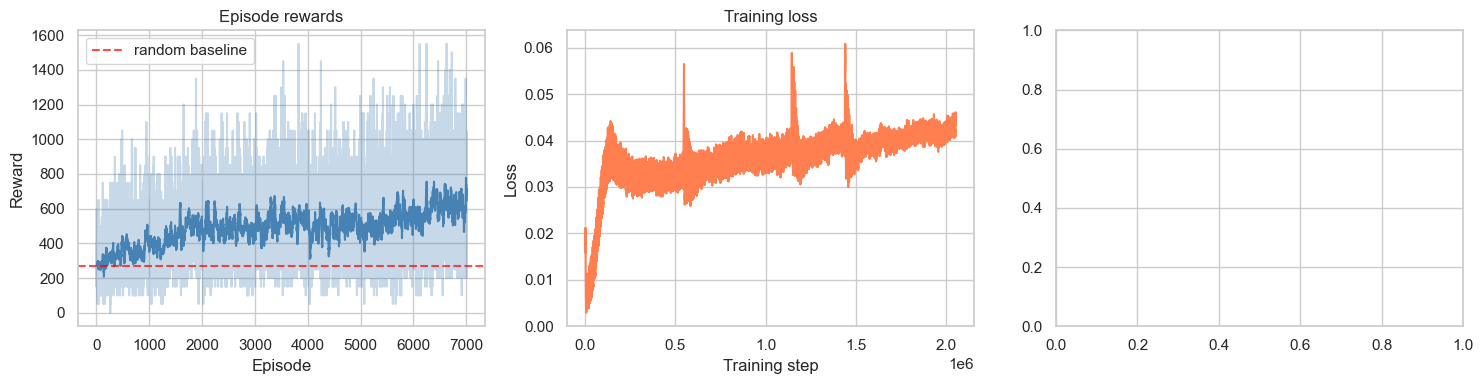

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def evaluate_agent(env, Q_net, device, n_episodes=20, eps=0.0):
    """Run n_episodes and return rewards. eps=0 for pure greedy, eps=0.05 for slight exploration."""
    Q_net.eval()
    rewards = []
    
    for ep in range(n_episodes):
        obs, info = env.reset()
        obs_t = process_obs(obs)
        done = False
        total = 0
        
        while not done:
            if random.random() > eps:
                with torch.no_grad():
                    action = Q_net(obs_t).argmax(dim=1).item()
            else:
                action = env.action_space.sample()
                
            obs, reward, terminated, truncated, info = env.step(action)
            obs_t = process_obs(obs)
            total += reward
            done = terminated or truncated
            
        rewards.append(total)
    
    Q_net.train()
    return rewards


def plot_training(episode_rewards, train_losses, eval_scores=None):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    
    # Raw + smoothed episode rewards
    rewards = np.array(episode_rewards)
    axes[0].plot(rewards, alpha=0.3, color='steelblue')
    if len(rewards) >= 20:
        smoothed = np.convolve(rewards, np.ones(20)/20, mode='valid')
        axes[0].plot(range(19, len(rewards)), smoothed, color='steelblue')
    axes[0].axhline(y=267, color='red', linestyle='--', alpha=0.7, label='random baseline')
    axes[0].set_title('Episode rewards')
    axes[0].set_xlabel('Episode')
    axes[0].set_ylabel('Reward')
    axes[0].legend()
    
    # Smoothed loss
    if len(train_losses) > 0:
        losses = np.array(train_losses)
        if len(losses) >= 1000:
            smoothed_loss = np.convolve(losses, np.ones(1000)/1000, mode='valid')
            axes[1].plot(smoothed_loss, color='coral')
        else:
            axes[1].plot(losses, color='coral')
    axes[1].set_title('Training loss')
    axes[1].set_xlabel('Training step')
    axes[1].set_ylabel('Loss')
    
    # Periodic eval scores
    if eval_scores and len(eval_scores) > 0:
        eval_means = [np.mean(s) for s in eval_scores]
        eval_stds  = [np.std(s)  for s in eval_scores]
        x = range(len(eval_means))
        axes[2].plot(eval_means, color='green')
        axes[2].fill_between(x,
            np.array(eval_means) - np.array(eval_stds),
            np.array(eval_means) + np.array(eval_stds),
            alpha=0.2, color='green')
        axes[2].axhline(y=267, color='red', linestyle='--', alpha=0.7, label='random baseline')
        axes[2].set_title('Eval score over time')
        axes[2].set_xlabel('Eval checkpoint')
        axes[2].set_ylabel('Mean reward')
        axes[2].legend()
    
    plt.tight_layout()
    plt.show()


# Add this list before your training loop
eval_scores = []

# Add this block inside your training loop every 200 episodes
if x % 200 == 0 and x > 0:
    scores = evaluate_agent(env, Q_net, device, n_episodes=10)
    eval_scores.append(scores)
    print(f"--- Eval at episode {x} | "
          f"mean={np.mean(scores):.1f} | "
          f"std={np.std(scores):.1f} | "
          f"best={np.max(scores):.1f} | "
          f"vs random=267 ---")

# Call this whenever you want to see the full picture
plot_training(episode_rewards, train_losses, eval_scores)

In [37]:
# Check what's actually happening in one episode
obs, info = env.reset()
obs = process_obs(obs)
done = False
steps = 0
while not done:
    action = env.action_space.sample()
    obs, reward, terminated, truncated, info = env.step(action)
    obs = process_obs(obs)
    steps += 1
    done = terminated or truncated
    if steps < 5:
        print(f"step={steps} reward={reward} terminated={terminated} truncated={truncated}")

print(f"Episode ended after {steps} steps")

step=1 reward=0.0 terminated=False truncated=False
step=2 reward=0.0 terminated=False truncated=False
step=3 reward=0.0 terminated=False truncated=False
step=4 reward=0.0 terminated=False truncated=False
Episode ended after 291 steps


In [14]:
# Run this on a fixed batch of states
def check_q_magnitude(Q_net, replay_buffer, device, n=500):
    sample = random.sample(replay_buffer, n)
    obss = torch.tensor(np.vstack([r[0] for r in sample]), device=device)
    with torch.no_grad():
        q_vals = Q_net(obss).max(dim=1).values
    print(f"Mean max-Q: {q_vals.mean().item():.3f}")
    print(f"Max  max-Q: {q_vals.max().item():.3f}")

check_q_magnitude(Q_net, replay_buffer, device)

Mean max-Q: 7.178
Max  max-Q: 12.631
